# Qwen-Image-2.1 on a free Colab T4 — text-to-image + a public API

Runs **Qwen-Image-2.1 Q4_K_M GGUF** (7B diffusion transformer) headless with
ComfyUI + the **Viggle turbo LoRA** (6 steps, CFG off), generates a sample
image, and prints a **public API URL** (Cloudflare quick tunnel — no account)
you can call from any machine.

- ⏱ **~10 minutes end to end** (install 1 min → downloads 3–4 min → boot 2 min
  → first image ~2 min → tunnel 15 s). Everything is measured; see the
  [repo](https://github.com/KodeIsFun/run-qwen-image-on-free-colab) for the
  numbers and the gotchas.
- ⚠️ **Requires the T4 runtime**: menu *Runtime → Change runtime type → T4
  GPU → Save* (free tier), then *Runtime → Run all*. Cell 1 checks and warns.
- 🖼 Settings are the measured turbo combo for the free T4: **768×768,
  6 steps, fp16, turbo LoRA, CFG off** → ~2.8 s/step, **~24 s per warm
  image** (the 12-step no-LoRA combo is ~69 s on the same weights). Text
  rendering works (try a prompt with words in it).
- ⚖️ Model: **Qwen Research License** (experiments/research/demos; check
  before commercial use).


In [ ]:
# Cell 1 — make sure this runtime actually has a GPU
import subprocess
out = ""
try:
    out = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True, text=True, timeout=30).stdout.strip()
except Exception:
    pass
if "T4" not in out:
    print("WARNING: expected a T4 GPU, got:", out or "no GPU at all")
    raise SystemExit("Menu: Runtime -> Change runtime type -> T4 GPU -> Save, "
                     "then Runtime -> Run all again.")
print("OK: gpu -", out)


OK: gpu - Tesla T4, 15360 MiB


In [ ]:
# Cell 2 — ComfyUI + the leejet ComfyUI-GGUF fork + Viggle's turbo node (idempotent)
import os, time
t0 = time.time()
if not os.path.isdir("/content/ComfyUI"):
    !git clone --depth 1 https://github.com/comfyanonymous/ComfyUI /content/ComfyUI
    !pip install -q -r /content/ComfyUI/requirements.txt
if not os.path.isdir("/content/ComfyUI/custom_nodes/ComfyUI-GGUF"):
    # the leejet fork, NOT city96 — city96 fails with "Unknown model architecture!"
    !git clone --depth 1 https://github.com/leejet/ComfyUI-GGUF /content/ComfyUI/custom_nodes/ComfyUI-GGUF
    !pip install -q -r /content/ComfyUI/custom_nodes/ComfyUI-GGUF/requirements.txt
if not os.path.exists("/content/ComfyUI/custom_nodes/viggle_turbo.py"):
    # Viggle's turbo custom node: applies the LoRA at runtime (never merge —
    # merging is lossy) and builds the resolution-shifted few-step sigmas that
    # stock ComfyUI samplers cannot express. Custom nodes load at server boot,
    # so this cell must run BEFORE the launch cell.
    !wget -q --tries=3 --timeout=60 https://huggingface.co/Viggle/Qwen-Image-2.1-viggle-turbo/resolve/main/comfyui/viggle_turbo.py -O /content/ComfyUI/custom_nodes/viggle_turbo.py
print(f"OK: install ({time.time() - t0:.0f}s)")


Cloning into '/content/ComfyUI'...


remote: Enumerating objects: 1386, done.
remote: Counting objects: 100% (1386/1386), done.
remote: Compressing objects: 100% (1185/1185), done.


remote: Total 1386 (delta 154), reused 1283 (delta 154), pack-reused 0 (from 0)
Receiving objects: 100% (1386/1386), 12.16 MiB | 15.60 MiB/s, done.
Resolving deltas

Resolving deltas: 100% (154/154), done.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.2/25.2 MB 80.3 MB/s eta 0:00:00


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 109.6 MB/s eta 0:00:00


Cloning into '/content/ComfyUI/custom_nodes/ComfyUI-GGUF'...


remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 19 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 34.62 KiB | 571.00 KiB/s, done.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 4.4 MB/s eta 0:00:00


OK: install (42s)


In [ ]:
# Cell 3 — download the model files (idempotent, resumes partial downloads)
import os, shutil, time
# The diffusion GGUF comes from unsloth: abenzerps' original repo was
# restructured to Uncensored-only and the base file 404s (GitHub issue #1).
# unsloth hosts the BASE model — the same distribution the turbo LoRA was
# distilled from. Text encoder + VAE still resolve at the original repo.
UNSLOTH = "https://huggingface.co/unsloth/Qwen-Image-2.1-GGUF/resolve/main"
ABENZ = "https://huggingface.co/abenzerps/Qwen-Image-2.1-GGUF/resolve/main"
VIGGLE = "https://huggingface.co/Viggle/Qwen-Image-2.1-viggle-turbo/resolve/main"
FILES = [
    (f"{UNSLOTH}/qwen-image-2.1-Q4_K_M.gguf",
     "/content/ComfyUI/models/diffusion_models/qwen-image-2.1-Q4_K_M.gguf"),
    (f"{ABENZ}/text_encoders/qwen3vl_8b_int8_convrot.safetensors",
     "/content/ComfyUI/models/text_encoders/qwen3vl_8b_int8_convrot.safetensors"),
    (f"{ABENZ}/vae/qwen_image_2.1_vae_bf16.safetensors",
     "/content/ComfyUI/models/vae/qwen_image_2.1_vae_bf16.safetensors"),
    (f"{VIGGLE}/Qwen-Image-2.1-viggle-turbo-v0.2.1-6step-lora-r256.safetensors",
     "/content/ComfyUI/models/loras/Qwen-Image-2.1-viggle-turbo-v0.2.1-6step-lora-r256.safetensors"),
]
t0 = time.time()
for url, dest in FILES:
    if os.path.exists(dest) and os.path.getsize(dest) > 1e8:
        print("cached:", os.path.basename(dest))
        continue
    print("downloading:", os.path.basename(dest))
    !wget -q -c --tries=3 --timeout=60 {url} -O {dest}
    assert os.path.getsize(dest) > 1e8, (
        f"download failed: {dest} — delete the partial file and re-run this "
        f"cell (repo troubleshooting §13)")
# loader-compat copies: some node versions scan models/unet and models/clip
os.makedirs("/content/ComfyUI/models/unet", exist_ok=True)
shutil.copy(FILES[0][1], "/content/ComfyUI/models/unet/")
os.makedirs("/content/ComfyUI/models/clip", exist_ok=True)
shutil.copy(FILES[1][1], "/content/ComfyUI/models/clip/")
print(f"OK: download ({time.time() - t0:.0f}s total, ~15.6 GB fresh)")


downloading: qwen-image-2.1-Q4_K_M.gguf


downloading: qwen3vl_8b_int8_convrot.safetensors


downloading: qwen_image_2.1_vae_bf16.safetensors


downloading: Qwen-Image-2.1-viggle-turbo-v0.2.1-6step-lora-r256.safetensors


OK: download (305s total, ~15.6 GB fresh)


In [ ]:
# Cell 4 — boot ComfyUI headless with the measured T4 flags (idempotent)
import subprocess, sys, time, urllib.request
BASE = "http://127.0.0.1:8188"
def alive():
    try:
        urllib.request.urlopen(BASE + "/system_stats", timeout=5)
        return True
    except Exception:
        return False
if alive():
    print("OK: launch (server already running — skipping boot)")
else:
    # --force-fp16: T4 has no bf16, so default cast is fp32 (~6x slower).
    # --disable-comfy-compiler: required with fp16 on the T4, else the first
    #   forward dies with "aimdo memory compile error" (ComfyUI model compiler).
    FLAGS = ["--force-fp16", "--disable-comfy-compiler"]
    log = open("/content/comfyui.log", "w")
    proc = subprocess.Popen(
        [sys.executable, "main.py", "--listen", "127.0.0.1", "--port", "8188", *FLAGS],
        cwd="/content/ComfyUI", stdout=log, stderr=subprocess.STDOUT)
    t0 = time.time()
    while not alive():
        if proc.poll() is not None or time.time() - t0 > 300:
            print(open("/content/comfyui.log").read()[-2000:])
            raise SystemExit("ComfyUI failed to boot - log tail above. "
                             "See the repo's troubleshooting guide.")
        time.sleep(3)
    print(f"OK: launch ({time.time() - t0:.0f}s)")


OK: launch (30s)


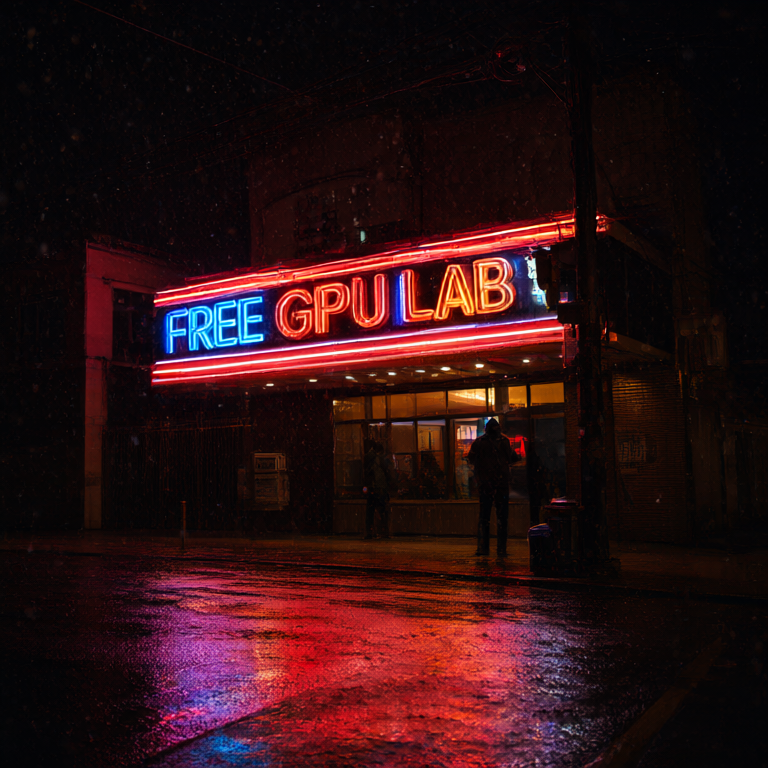

OK: generate (75s incl. first-time model loads; warm images run ~24 s) -> /content/qwen-sample.png


In [ ]:
# Cell 5 — verify the graph nodes exist, then generate the sample image
import json, time, urllib.parse, urllib.request
from IPython.display import Image as IPyImage, display
BASE = "http://127.0.0.1:8188"
def api(path, payload=None, timeout=60):
    if payload is None:
        req = urllib.request.Request(BASE + path)
    else:
        req = urllib.request.Request(BASE + path, data=json.dumps(payload).encode(),
                                     method="POST",
                                     headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return json.loads(r.read())

oi = api("/object_info")
assert "UnetLoaderGGUF" in oi, "GGUF loader missing - is ComfyUI-GGUF (leejet) installed?"
assert "ViggleTurboLora" in oi and "ViggleTurboSigmas" in oi, (
    "viggle_turbo custom node missing - re-run cell 2, then Restart runtime "
    "(custom nodes load at server boot)")
clip_types = oi["CLIPLoader"]["input"].get("required", {}).get("type") or              oi["CLIPLoader"]["input"].get("optional", {}).get("type")
assert "qwen_image" in clip_types[0], "CLIPLoader lacks the qwen_image type - update ComfyUI"

# The measured turbo combo: 768x768, 6 steps, cfg fully OFF (BasicGuider runs
# no negative pass), ViggleTurboSigmas schedule, runtime-hook LoRA. ~24 s warm.
wf = {
    "1": {"class_type": "UnetLoaderGGUF",
          "inputs": {"unet_name": "qwen-image-2.1-Q4_K_M.gguf"}},
    "2": {"class_type": "CLIPLoader",
          "inputs": {"clip_name": "qwen3vl_8b_int8_convrot.safetensors", "type": "qwen_image"}},
    "3": {"class_type": "VAELoader",
          "inputs": {"vae_name": "qwen_image_2.1_vae_bf16.safetensors"}},
    "4": {"class_type": "CLIPTextEncode",
          "inputs": {"clip": ["2", 0],
                     "text": 'a neon shop sign that reads "FREE GPU LAB", rainy night, reflections on wet pavement'}},
    "5": {"class_type": "ViggleTurboLora",
          "inputs": {"model": ["1", 0],
                     "lora_name": "Qwen-Image-2.1-viggle-turbo-v0.2.1-6step-lora-r256.safetensors",
                     "strength": 1.0}},
    "6": {"class_type": "EmptySD3LatentImage",
          "inputs": {"width": 768, "height": 768, "batch_size": 1}},
    "7": {"class_type": "RandomNoise", "inputs": {"noise_seed": 42}},
    "8": {"class_type": "KSamplerSelect", "inputs": {"sampler_name": "euler"}},
    "9": {"class_type": "ViggleTurboSigmas",
          "inputs": {"latent": ["6", 0], "nodes": "1.0, 0.9375, 0.875, 0.75, 0.5, 0.25"}},
    "10": {"class_type": "BasicGuider",
           "inputs": {"model": ["5", 0], "conditioning": ["4", 0]}},
    "11": {"class_type": "SamplerCustomAdvanced",
           "inputs": {"noise": ["7", 0], "guider": ["10", 0], "sampler": ["8", 0],
                      "sigmas": ["9", 0], "latent_image": ["6", 0]}},
    "12": {"class_type": "VAEDecode",
           "inputs": {"samples": ["11", 0], "vae": ["3", 0]}},
    "13": {"class_type": "SaveImage",
           "inputs": {"images": ["12", 0], "filename_prefix": "qwen_t4_sample"}},
}
pid = api("/prompt", {"prompt": wf, "client_id": "notebook"})["prompt_id"]
t0 = time.time()
imgs = []
while time.time() - t0 < 1500:
    time.sleep(3)
    hist = api(f"/history/{pid}", timeout=20)
    if pid not in hist:
        continue
    entry = hist[pid]
    if entry.get("status", {}).get("status_str") == "error":
        print(json.dumps(entry["status"].get("messages", []))[:800])
        raise SystemExit("generation failed - see the repo's troubleshooting guide")
    imgs = [im for out in entry.get("outputs", {}).values() for im in out.get("images", [])]
    if imgs:
        break
assert imgs, "timeout waiting for the image"
q = urllib.parse.urlencode({"filename": imgs[0]["filename"],
                            "subfolder": imgs[0].get("subfolder", ""),
                            "type": imgs[0].get("type", "output")})
data = urllib.request.urlopen(f"{BASE}/view?{q}", timeout=120).read()
open("/content/qwen-sample.png", "wb").write(data)
display(IPyImage("/content/qwen-sample.png"))
print(f'OK: generate ({time.time() - t0:.0f}s incl. first-time model loads; '
      f'warm images run ~24 s) -> /content/qwen-sample.png')


In [ ]:
# Cell 6 — expose the API through a public quick tunnel (no account needed)
import os, re, subprocess, time
CF = "/content/cloudflared"
if not os.path.exists(CF):
    !wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O {CF}
    !chmod +x {CF}
subprocess.run(["pkill", "-f", "cloudflared tunnel"], check=False)  # fresh URL on re-run
time.sleep(1)
tun_log = open("/content/cloudflared.log", "w")
subprocess.Popen([CF, "tunnel", "--url", "http://localhost:8188", "--no-autoupdate"],
                 stdout=tun_log, stderr=subprocess.STDOUT)
url = None
t0 = time.time()
while url is None and time.time() - t0 < 60:
    time.sleep(2)
    m = re.search(r"https://[a-z0-9-]+\.trycloudflare\.com",
                  open("/content/cloudflared.log").read())
    url = m.group(0) if m else None
assert url, "tunnel failed - see /content/cloudflared.log"
print("API URL:", url)
print("OK: tunnel")


API URL: https://hammer-representations-bike-completion.trycloudflare.com
OK: tunnel


In [ ]:
# Cell 7 — copy-paste usage with YOUR tunnel URL filled in
print(f"""
Your text-to-image API is live from anywhere (while this notebook runs):

  python3 txt2img.py --url {url} \\
      --prompt 'a red fox in snow, film photo' --out fox.png

Defaults to the turbo graph (6 steps, CFG off, ~24 s warm). For the slower
no-LoRA baseline: add --no-turbo (12 steps, cfg 2.5, ~69 s warm).

(txt2img.py ships in the repo under clients/ - it needs only Python 3,
no installs. The URL changes every notebook re-run.)

Raw HTTP works too:
  curl {url}/system_stats
""")
print("OK: api")



Your text-to-image API is live from anywhere (while this notebook runs):

  python3 txt2img.py --url https://hammer-representations-bike-completion.trycloudflare.com \
      --prompt 'a red fox in snow, film photo' --out fox.png

Defaults to the turbo graph (6 steps, CFG off, ~24 s warm). For the slower
no-LoRA baseline: add --no-turbo (12 steps, cfg 2.5, ~69 s warm).

(txt2img.py ships in the repo under clients/ - it needs only Python 3,
no installs. The URL changes every notebook re-run.)

Raw HTTP works too:
  curl https://hammer-representations-bike-completion.trycloudflare.com/system_stats

OK: api


## Tweaking cheat sheet (all measured on this exact setup)

| Change | Effect |
|---|---|
| turbo (default) → `--no-turbo` | 6-step LoRA graph → 12-step no-LoRA baseline: ~24 s → ~69 s warm; keep the baseline if the custom node ever breaks on a newer ComfyUI |
| turbo, small dense text | 8 steps instead of 6: the v0.2.1 card's official small-text schedule `1.0, 0.9375, 0.875, 0.75, 0.625, 0.5, 0.25, 0.125`, ~27 s, text canary intact |
| `width/height: 768` → 1024 | ~1.8× slower per step; quality up |
| `steps: 12` → 16, 20 (baseline) | better fine detail, linearly slower (20 steps fp32 = 12.8 min/image — don't) |
| sampler / scheduler | turbo: euler + ViggleTurboSigmas (the schedule is the recipe). baseline: `res_multistep`/`simple`; speed barely moves (compute-bound) |
| smaller quant (Q5/Q4_0) | **no speed change** — the step is compute-bound; quants decide what fits in VRAM |

Gotchas that will bite if forgotten (full list in the repo's
`references/05-troubleshooting.md`):

- The T4 needs BOTH `--force-fp16` and `--disable-comfy-compiler` (cell 4 has
  them). Without fp16: ~6× slower. Without the compiler flag: crash.
- The GGUF needs the **leejet** fork of ComfyUI-GGUF (cell 2 uses it).
- The turbo LoRA is applied at runtime by the author's custom node and must
  **never be merged** into the weights (merging is lossy); CFG stays fully
  off — that is part of the recipe, not a shortcut.
- The diffusion GGUF comes from **unsloth** (abenzerps' original 404s —
  GitHub issue #1); the turbo LoRA was distilled on that base distribution.
- The tunnel URL is new on every run; the VM sleeps when idle.

When finished: *Runtime → Manage sessions → TERMINATE* — free GPU minutes are
a shared budget.
